# Lab 1: Understanding Deep Learning Requires Rethinking Generalization

### Introduction

This lab is based on the paper ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/abs/1611.03530) by Zhang et al. (ICLR 2017). The paper presents a striking observation: deep neural networks can easily memorize training data with **completely random labels**, achieving near-perfect training accuracy while (unsurprisingly) failing to generalize.

This challenges classical learning theory, which suggests that models with enough capacity to memorize noise should generalize poorly even on real data. Yet in practice, the same overparameterized networks generalize remarkably well on true labels.

### Objectives

1. Observe that overparameterized networks achieve near-perfect training accuracy on MNIST
2. Demonstrate that the same network can memorize **random labels** (zero generalization)
3. Investigate the effect of **model capacity** (hidden size) on training and generalization
4. Test whether **weight decay regularization** can prevent memorization or improve generalization
5. Discuss what these results mean for classical generalization theory

### Setup

We begin by importing the necessary libraries and preparing the MNIST dataset. We use a **10,000-sample subset** of the training data — this keeps training fast while still being sufficient to demonstrate the generalization phenomena from the paper (the model is heavily overparameterized relative to the dataset size). The device is auto-detected to work on CUDA, MPS (Apple Silicon), or CPU.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# Auto-detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

transform = transforms.Compose([transforms.ToTensor()])
batch_size = 256

full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

# Use a 10k subset for training — fast and still heavily overparameterized
subset_size: int = 10_000
train_dataset = Subset(full_train_dataset, list(range(subset_size)))

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Using device: cuda
Training samples: 10000, Test samples: 10000


### Explore the Data

Let's visualize a few samples from the MNIST dataset to understand what we're working with.

Batch shape: torch.Size([256, 1, 28, 28])
Target shape: torch.Size([256])


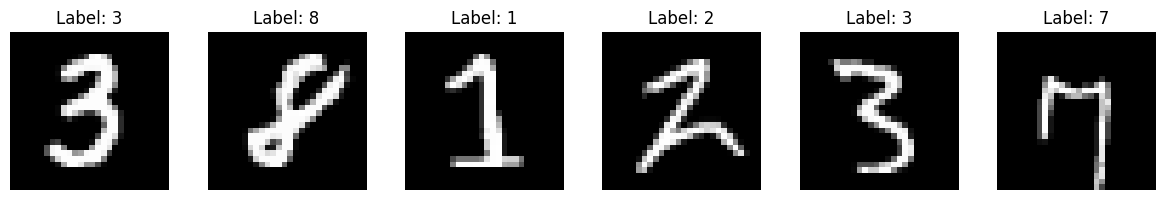

In [14]:
examples = iter(train_loader)
example_data, example_targets = next(examples)

print(f"Batch shape: {example_data.shape}")  # [batch_size, channels, height, width]
print(f"Target shape: {example_targets.shape}")  # [batch_size]

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(example_data[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {example_targets[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Exercise 1: Define the Model

Implement a 3-layer MLP (Multi-Layer Perceptron) for MNIST classification. The architecture should be:

- **Input**: Flattened 28×28 image → 784 features
- **Hidden layer 1**: Linear(784, hidden_size) + ReLU
- **Hidden layer 2**: Linear(hidden_size, hidden_size) + ReLU
- **Output layer**: Linear(hidden_size, 10)

The `hidden_size` parameter controls model capacity — we will experiment with different values later.

In [15]:
class Net(nn.Module):
    def __init__(
        self, input_size: int = 784, hidden_size: int = 1024, num_classes: int = 10
    ) -> None:
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Training Utilities

The following helper functions are provided for training and evaluation. The `train_model` function:
1. Creates a `Net` with the specified `hidden_size`
2. Trains using Adam optimizer with cross-entropy loss
3. Tracks both **train** and **test** accuracy after each epoch
4. Returns the accuracy histories for plotting

In [16]:
def evaluate(model: nn.Module, data_loader: DataLoader) -> float:
    """Compute accuracy on a dataset."""
    model.eval()
    correct: int = 0
    total: int = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def train_model(
    train_loader: DataLoader,
    test_loader: DataLoader,
    hidden_size: int = 1024,
    num_epochs: int = 10,
    weight_decay: float = 0.0,
) -> tuple[list[float], list[float], nn.Module]:
    """Train a Net and return (train_accuracies, test_accuracies, model)."""
    model: nn.Module = Net(hidden_size=hidden_size).to(device)
    criterion: nn.Module = nn.CrossEntropyLoss()
    optimizer: optim.Optimizer = optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=weight_decay
    )

    train_accuracies: list[float] = []
    test_accuracies: list[float] = []

    for epoch in range(num_epochs):
        model.train()
        running_loss: float = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss: float = running_loss / len(train_loader)
        train_acc: float = evaluate(model, train_loader)
        test_acc: float = evaluate(model, test_loader)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}"
        )

    return train_accuracies, test_accuracies, model

### Exercise 2: Train on True Labels

Train the model on the original MNIST labels using `hidden_size=1024` and `num_epochs=5`. Store the results and plot the train/test accuracy curves.

**Task:**
1. Call `train_model` with the true-label data loaders
2. Plot train accuracy and test accuracy vs. epoch on the same axes
3. Observe: does the model generalize well?

Epoch [1/5], Loss: 0.6635, Train Acc: 0.9203, Test Acc: 0.9056
Epoch [2/5], Loss: 0.2643, Train Acc: 0.9410, Test Acc: 0.9214
Epoch [3/5], Loss: 0.1737, Train Acc: 0.9635, Test Acc: 0.9382
Epoch [4/5], Loss: 0.1290, Train Acc: 0.9695, Test Acc: 0.9388
Epoch [5/5], Loss: 0.1009, Train Acc: 0.9812, Test Acc: 0.9459


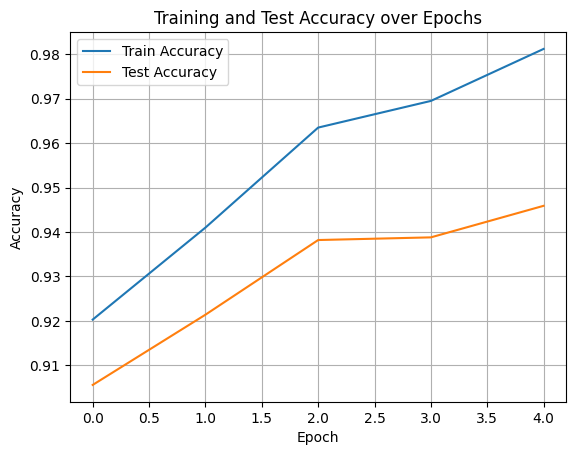

In [17]:
train_accuracies, test_accuracies, model = train_model(train_loader, test_loader, num_epochs=5, hidden_size=1024)

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy over Epochs")
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-info">
<b>Comment:</b> The model achieves very high training accuracy and high test accuracy. Achieving almost 100% accuracy on the training test may suggest overfitting, however, since the test accuracy remains high and continues to improve, the model still generalizes reasonably well.
</div>

### Exercise 3: Random Labels Experiment

This is the **key experiment** from the paper. We replace the true labels with **completely random labels** drawn uniformly from {0, 1, ..., 9}. Since the labels have no correlation with the images, a model that achieves high training accuracy is simply **memorizing** the dataset.

**Task:**
1. Implement the `RandomLabels` dataset wrapper below
2. Create data loaders with random labels (wrap the existing `train_dataset`)
3. Train the model for **25 epochs** (memorization takes longer than learning true patterns)
4. Observe: can the network memorize random labels? What happens to test accuracy?

In [18]:
class RandomLabels(Dataset):
    """Wraps a dataset and replaces labels with random ones."""

    def __init__(self, base_dataset: Dataset, num_classes: int = 10, seed: int = 42) -> None:
        self.base: Dataset = base_dataset
        self.random_labels: torch.Tensor = torch.randint(
            low=0,
            high=num_classes,
            size=(len(base_dataset,),),
            generator=torch.Generator().manual_seed(seed),
        )

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        image, _ = self.base[idx]
        label = self.random_labels[idx].item()
        return image, int(label)

In [19]:
random_train_dataset = RandomLabels(train_dataset)
random_test_dataset = RandomLabels(test_dataset)

random_train_loader = DataLoader(dataset=random_train_dataset, batch_size=batch_size, shuffle=True)
random_test_loader = DataLoader(dataset=random_test_dataset, batch_size=batch_size, shuffle=False)

random_train_accuracies, random_test_accuracies, random_model = train_model(
    random_train_loader, random_test_loader, hidden_size=1024, num_epochs=25
)

Epoch [1/25], Loss: 2.3062, Train Acc: 0.1117, Test Acc: 0.1005
Epoch [2/25], Loss: 2.2984, Train Acc: 0.1371, Test Acc: 0.1014
Epoch [3/25], Loss: 2.2900, Train Acc: 0.1647, Test Acc: 0.1015
Epoch [4/25], Loss: 2.2683, Train Acc: 0.1792, Test Acc: 0.1013
Epoch [5/25], Loss: 2.2435, Train Acc: 0.2234, Test Acc: 0.0983
Epoch [6/25], Loss: 2.1959, Train Acc: 0.2402, Test Acc: 0.1023
Epoch [7/25], Loss: 2.1312, Train Acc: 0.3115, Test Acc: 0.1006
Epoch [8/25], Loss: 2.0455, Train Acc: 0.3299, Test Acc: 0.1033
Epoch [9/25], Loss: 1.9449, Train Acc: 0.3958, Test Acc: 0.1001
Epoch [10/25], Loss: 1.8256, Train Acc: 0.4202, Test Acc: 0.1023
Epoch [11/25], Loss: 1.7058, Train Acc: 0.4713, Test Acc: 0.1038
Epoch [12/25], Loss: 1.5824, Train Acc: 0.5436, Test Acc: 0.0978
Epoch [13/25], Loss: 1.4430, Train Acc: 0.5659, Test Acc: 0.0998
Epoch [14/25], Loss: 1.3003, Train Acc: 0.6406, Test Acc: 0.0983
Epoch [15/25], Loss: 1.1803, Train Acc: 0.6900, Test Acc: 0.0980
Epoch [16/25], Loss: 1.0923, Train

### Exercise 4: Comparison Plot

Create a side-by-side comparison of training on **true labels** vs. **random labels**.

**Task:**
1. Create a figure with 2 subplots
2. Left subplot: true labels — plot train accuracy, test accuracy, and generalization gap
3. Right subplot: random labels — plot train accuracy, test accuracy, and generalization gap
4. The **generalization gap** is defined as `train_accuracy - test_accuracy`

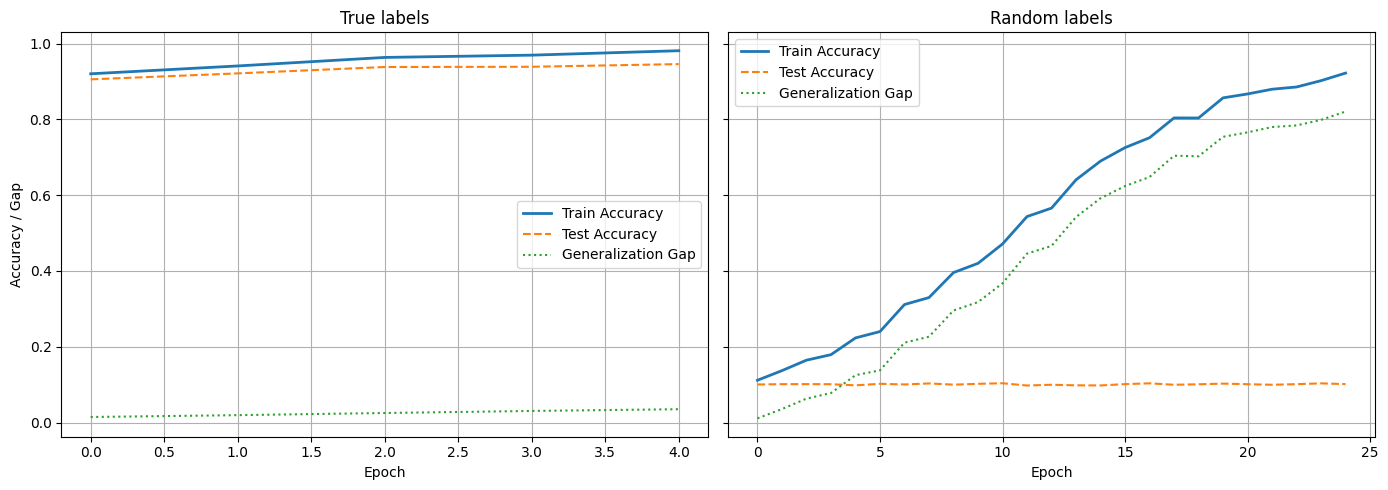

In [20]:
generalization_gap = [train_acc - test_acc for train_acc, test_acc in zip(train_accuracies, test_accuracies)]
random_generalization_gap = [train_acc - test_acc for train_acc, test_acc in zip(random_train_accuracies, random_test_accuracies)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# True labels
axes[0].plot(train_accuracies, label="Train Accuracy", linewidth=2)
axes[0].plot(test_accuracies, label="Test Accuracy", linestyle="--")
axes[0].plot(generalization_gap, label="Generalization Gap", linestyle=":")
axes[0].set_title("True labels")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy / Gap")
axes[0].legend()
axes[0].grid(True)

# Random labels
axes[1].plot(random_train_accuracies, label="Train Accuracy", linewidth=2)
axes[1].plot(random_test_accuracies, label="Test Accuracy", linestyle="--")
axes[1].plot(random_generalization_gap, label="Generalization Gap", linestyle=":")
axes[1].set_title("Random labels")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<b>Comment:</b> It is now evident that the model is memorizing the data. It "learns" to predict completely random labels, which makes no sense. The test accuracy remains at approximately 10%, which corresponds to random guessing. The generalization gap stays at a stable level for real labels but increases for random ones.
</div>

### Exercise 5: Effect of Model Capacity

How does the size of the hidden layers affect the model's ability to fit and generalize?

**Task:**
1. Train models with `hidden_size` values `[50, 100, 200, 500, 1024]` on **true labels** for 10 epochs each
2. Record the **final** train and test accuracy for each hidden size
3. Plot final train accuracy and test accuracy vs. hidden size
4. Discuss: does a bigger model lead to worse generalization?

In [21]:
hidden_sizes = [50, 100, 200, 500, 1024]
final_train_accuracies = []
final_test_accuracies = []

for hidden_size in hidden_sizes:
    train_accs, test_accs, _ = train_model(
        train_loader, test_loader, hidden_size=hidden_size, num_epochs=10
    )
    final_train_accuracies.append(train_accs[-1])
    final_test_accuracies.append(test_accs[-1])

Epoch [1/10], Loss: 1.7944, Train Acc: 0.7990, Test Acc: 0.7937
Epoch [2/10], Loss: 0.7012, Train Acc: 0.8703, Test Acc: 0.8649
Epoch [3/10], Loss: 0.4154, Train Acc: 0.9014, Test Acc: 0.8900
Epoch [4/10], Loss: 0.3366, Train Acc: 0.9094, Test Acc: 0.8998
Epoch [5/10], Loss: 0.2997, Train Acc: 0.9199, Test Acc: 0.9070
Epoch [6/10], Loss: 0.2732, Train Acc: 0.9240, Test Acc: 0.9089
Epoch [7/10], Loss: 0.2571, Train Acc: 0.9320, Test Acc: 0.9149
Epoch [8/10], Loss: 0.2380, Train Acc: 0.9352, Test Acc: 0.9170
Epoch [9/10], Loss: 0.2282, Train Acc: 0.9373, Test Acc: 0.9159
Epoch [10/10], Loss: 0.2192, Train Acc: 0.9417, Test Acc: 0.9204
Epoch [1/10], Loss: 1.4616, Train Acc: 0.8159, Test Acc: 0.8084
Epoch [2/10], Loss: 0.4741, Train Acc: 0.9016, Test Acc: 0.8929
Epoch [3/10], Loss: 0.3314, Train Acc: 0.9175, Test Acc: 0.9067
Epoch [4/10], Loss: 0.2777, Train Acc: 0.9253, Test Acc: 0.9133
Epoch [5/10], Loss: 0.2463, Train Acc: 0.9253, Test Acc: 0.9084
Epoch [6/10], Loss: 0.2268, Train Acc: 

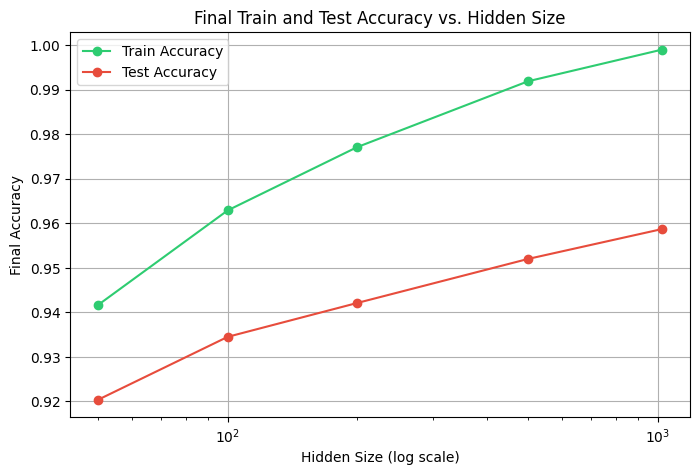

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(hidden_sizes, final_train_accuracies, marker='o', label='Train Accuracy', color='#2ecc71')
plt.plot(hidden_sizes, final_test_accuracies, marker='o', label='Test Accuracy', color='#e74c3c')
plt.xscale('log')
plt.xlabel("Hidden Size (log scale)")
plt.ylabel("Final Accuracy")
plt.title("Final Train and Test Accuracy vs. Hidden Size")
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-info">
<b>Comment:</b> As the hidden size increases, the model achieves higher training accuracy, 
reaching near-perfect performance for the largest model. Test accuracy also improves with model size, 
which suggests that the additional capacity is beneficial in this setting. At the same time, the gap 
between training and test accuracy becomes larger, indicating a higher tendency to overfit for bigger models.
</div>

### Exercise 6: Weight Decay Regularization

The paper argues that explicit regularization (such as weight decay) is **neither necessary nor sufficient** for generalization. Let's test this claim empirically.

Weight decay (L2 regularization) adds a penalty term $\lambda \|\mathbf{w}\|^2$ to the loss, discouraging large weights. The `train_model` function already supports a `weight_decay` parameter that is passed to the Adam optimizer.

We already know from Exercise 2 that the unregularized model generalizes well on true labels. The more interesting question is: **can weight decay prevent the network from memorizing random labels?**

**Task:**
1. Train models with `weight_decay` values `[1e-3, 1e-2, 1e-1]` on **random labels** for 10 epochs each (`hidden_size=1024`)
2. Plot final train accuracy vs. weight decay
3. Discuss: does weight decay prevent memorization? What does this say about the paper's claim?

In [24]:
weight_decays: list[float] = [1e-3, 1e-2, 1e-1]

final_train_accuracies = []
final_test_accuracies = []

for weight_decay in weight_decays:
    train_accs, test_accs, _ = train_model(
        random_train_loader, random_test_loader, hidden_size=1024, num_epochs=10, weight_decay=weight_decay
    )
    final_train_accuracies.append(train_accs[-1])
    final_test_accuracies.append(test_accs[-1])


Epoch [1/10], Loss: 2.3054, Train Acc: 0.1092, Test Acc: 0.1054
Epoch [2/10], Loss: 2.3009, Train Acc: 0.1316, Test Acc: 0.1037
Epoch [3/10], Loss: 2.2984, Train Acc: 0.1112, Test Acc: 0.1033
Epoch [4/10], Loss: 2.2982, Train Acc: 0.1254, Test Acc: 0.0984
Epoch [5/10], Loss: 2.2944, Train Acc: 0.1277, Test Acc: 0.1013
Epoch [6/10], Loss: 2.2927, Train Acc: 0.1373, Test Acc: 0.0980
Epoch [7/10], Loss: 2.2868, Train Acc: 0.1438, Test Acc: 0.0979
Epoch [8/10], Loss: 2.2836, Train Acc: 0.1522, Test Acc: 0.1012
Epoch [9/10], Loss: 2.2780, Train Acc: 0.1587, Test Acc: 0.1003
Epoch [10/10], Loss: 2.2699, Train Acc: 0.1683, Test Acc: 0.0966
Epoch [1/10], Loss: 2.3039, Train Acc: 0.1053, Test Acc: 0.1053
Epoch [2/10], Loss: 2.3026, Train Acc: 0.1056, Test Acc: 0.1056
Epoch [3/10], Loss: 2.3024, Train Acc: 0.1056, Test Acc: 0.1056
Epoch [4/10], Loss: 2.3021, Train Acc: 0.1056, Test Acc: 0.1056
Epoch [5/10], Loss: 2.3019, Train Acc: 0.1056, Test Acc: 0.1056
Epoch [6/10], Loss: 2.3017, Train Acc: 

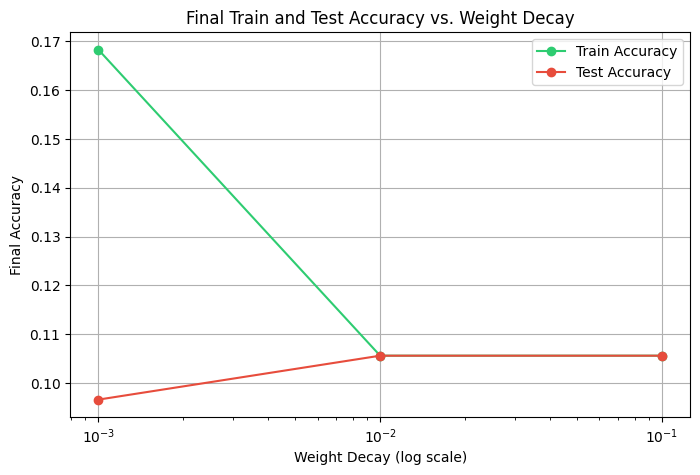

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(weight_decays, final_train_accuracies, marker='o', label='Train Accuracy', color='#2ecc71')
plt.plot(weight_decays, final_test_accuracies, marker='o', label='Test Accuracy', color='#e74c3c')
plt.xlabel("Weight Decay (log scale)")
plt.ylabel("Final Accuracy")
plt.title("Final Train and Test Accuracy vs. Weight Decay")
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-info">
<b>Comment:</b> In this experiment, increasing weight decay reduces the model's ability to memorize the randomly labeled training data. With strong regularization, both training and test accuracy stay near 0.1.
</div>

Compare our experimental setup and results with those reported in the paper. To what extent do our findings align with the original study? What similarities and discrepancies can be identified?

<div class="alert alert-block alert-info">

<b>Comment:</b> Although our setup is simpler (using MNIST instead of CIFAR-10 or ImageNet, and a 3-layer fully connected network without dropout or augmentation) we can still observe key similarities to the paper's findings. First, reaching 10% test accuracy on random labels is expected, but gives us a lesson that high training performance always requires deeper investigation before concluding that a model has truly learned. Furthermore, our experiment confirms that weight decay is not "itself sufficient", as it failed to prevent the model from overfitting to the random noise at lower regularization scales.

</div>

### Discussion Questions

**Q1:** In Exercise 6, you tested whether weight decay can prevent memorization or improve generalization. The paper's central claim is that explicit regularization is "neither necessary nor sufficient" for generalization. Based on your results, do you agree? If an unregularized model already generalizes well on true labels, what role (if any) does regularization actually play in deep learning?

**Q2:** The paper has over 6,000 citations, yet at its core it is based on a very simple experiment: training on random labels. Why do you think something so straightforward ended up having such a big impact on the field? What does this tell us about the value of empirical work vs. theoretical work in machine learning?

<div class="alert alert-block alert-info">
<b>Comment:</b> As stated previously, our version of the problem is much simpler than the one studied in the paper, so I do not think it is justified to make such a broad claim based only on our results. In our experiment, regularization did not seem particularly helpful, and I believe that in a well-designed model it may not always be necessary, since generalization can also arise from other factors. Regularization penalizes large weights and may reduce overfitting, but if a model already generalizes well, introducing an additional hyperparameter may not be necessary.

I think the paper is so highly cited because it showed, through a very simple experiment, that some common intuitions about generalization were incomplete. It highlights that both empirical and theoretical work are important in machine learning: empirical results can reveal surprising or counterintuitive behavior, while theory is needed to explain why that behavior occurs.
</div>